# Exercise 1

We first load a dataset and examine its dimensions.

In [10]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [11]:
import math
import numpy as np

xy_data = np.load('Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

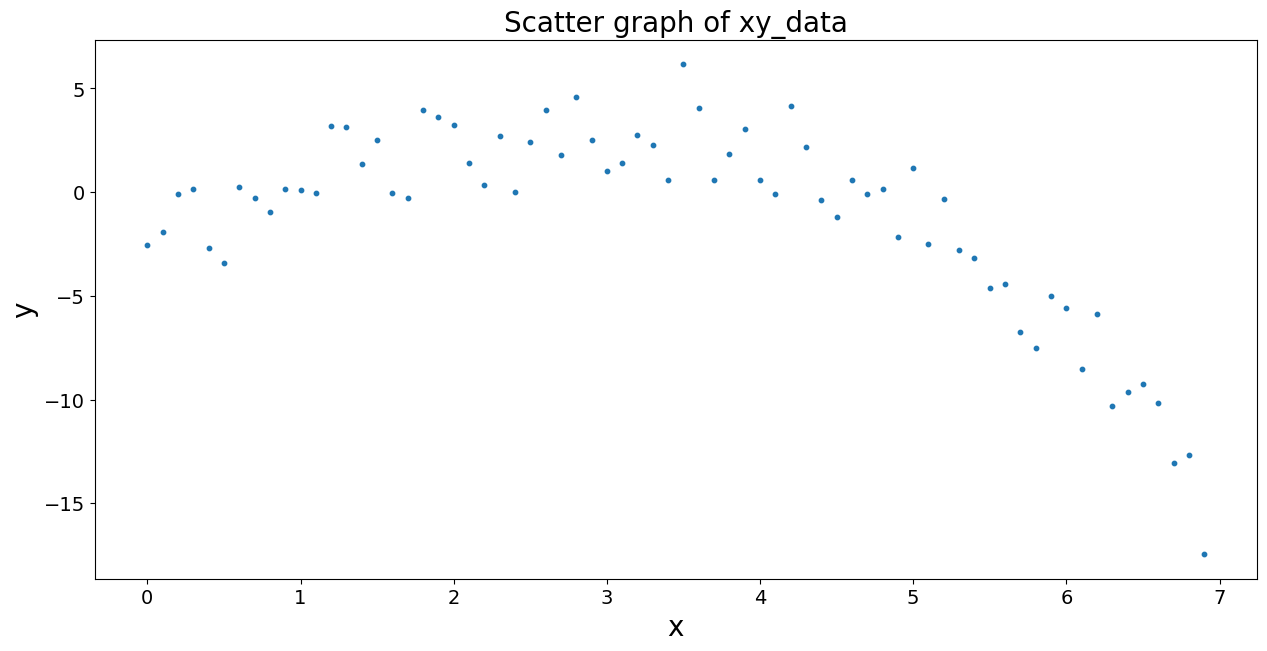

In [12]:
import matplotlib.pyplot as plt

x_data = xy_data[:,0]      # First column of array
y_data = xy_data[:,1]  # Second column of array 



plt.rcParams['figure.figsize'] = [15, 7]
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.scatter(x_data, y_data, s=10)   # s can be used to adjust the size of the dots
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter graph of xy_data')

plt.show()



### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset. 
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals. 

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [13]:
def polyreg(data_matrix, k):

    N = np.shape(data_matrix)[0]

    if k<N:
        order=k
    else:
        order=N-1

    x_data = data_matrix[:,0]  
    y_data = data_matrix[:,1]

  
    X = np.column_stack([x_data**i for i in range (0,order+1)])
    XT= X.T 
    
    betas = np.linalg.inv(XT.dot(X)).dot(XT.dot(y_data)) 
    fit = X.dot(betas)
    resid = y_data - fit


    #appending additional zeros
    betas=np.append(betas,[0 for i in range(order,k)])
    # The function should return the the coefficient vector beta, the fit, and the vector of residuals  
    return(betas,fit,resid)
    

Use the tests below to check the outputs of the function you have written:

In [14]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0] 
assert((np.round(beta_test[0], 3) == 2) and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))  
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included. 
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

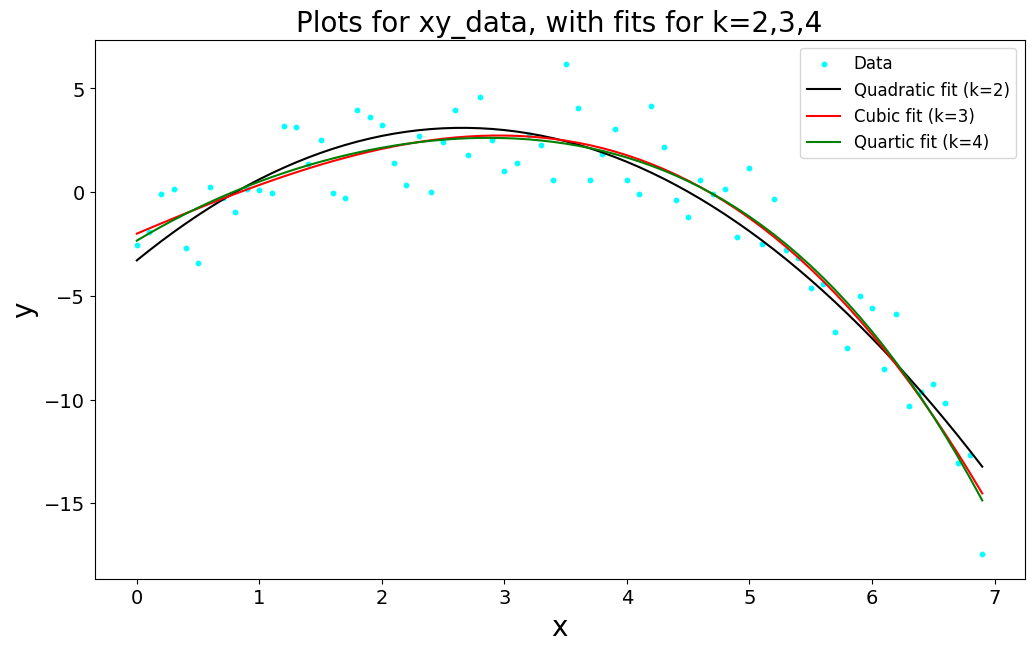

SSE_0 =  1532.27
SSE_2 =  172.18  	 R^2_2 =  0.8876
SSE_3 =  152.41  	 R^2_3 =  0.9005
SSE_4 =  151.23  	 R^2_4 =  0.9013


In [15]:
fit_0 = np.full_like(y_data, np.mean(y_data)) 
betas_2,fit_2,resid_2 = polyreg(xy_data, k=2)   # Computing the fit of the quadratic model
betas_3,fit_3,resid_3 = polyreg(xy_data, k=3)   # Computing the fit of the cubic model
betas_4,fit_4,resid_4 = polyreg(xy_data, k=4)   # Computing the fit of the quartic model

plt.rcParams['figure.figsize'] = [12, 7]

plt.scatter(x_data, y_data, s=10, color = 'cyan', label = 'Data')   
plt.plot(x_data, fit_2, color = 'black', label = 'Quadratic fit (k=2)')
plt.plot(x_data, fit_3, color = 'red', label = 'Cubic fit (k=3)')
plt.plot(x_data, fit_4, color = 'green', label = 'Quartic fit (k=4)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Plots for xy_data, with fits for k=2,3,4')
plt.legend(fontsize = 'large')

plt.show()


#We now compute the sum of squared errors
SSE_0 = np.linalg.norm(y_data - fit_0)**2
SSE_2 = np.linalg.norm(y_data - fit_2)**2
SSE_3 = np.linalg.norm(y_data - fit_3)**2
SSE_4 = np.linalg.norm(y_data - fit_4)**2

print('SSE_0 = ', np.round(SSE_0, 2))  
print('SSE_2 = ', np.round(SSE_2, 2), ' \t R^2_2 = ', np.round(1- SSE_2/SSE_0, decimals = 4))
print('SSE_3 = ', np.round(SSE_3, 2), ' \t R^2_3 = ', np.round(1- SSE_3/SSE_0, decimals = 4))
print('SSE_4 = ', np.round(SSE_4, 2), ' \t R^2_4 = ', np.round(1- SSE_4/SSE_0, decimals = 4))





 #### State which model you choose and briefly justify your choice.
 
 
The best model to use would probably be the cubic model, as it offers a noticable improvement in accuracy compared to the quadratic model, and is similar in goodness of fit to the quartic model - while being simpler. The simplest model with the best accuracy is most valuable for predicting future data.
 
 

### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot. 
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

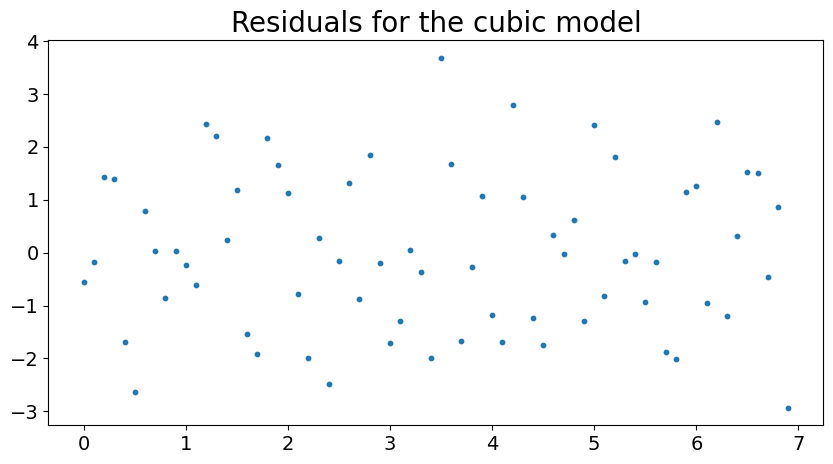

Mean of residuals for cubic model =  0.0 Variance of residuals =  2.177


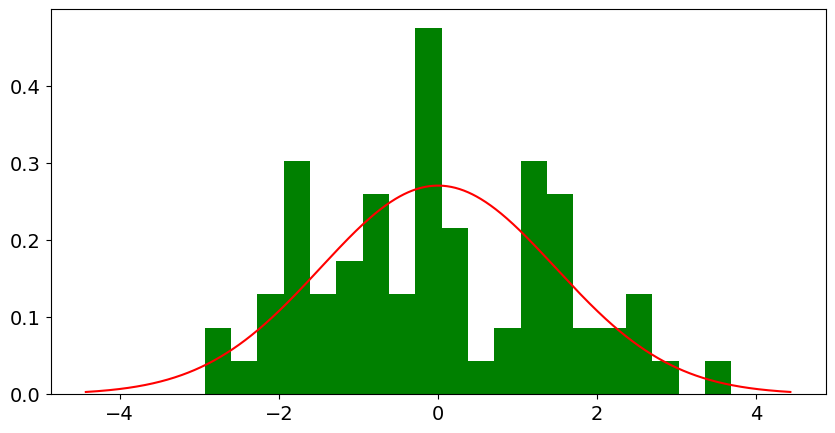

In [16]:
from scipy.stats import norm

plt.rcParams['figure.figsize'] = [10, 5]
plt.scatter(x_data, resid_3, s=10)
plt.title('Residuals for the cubic model')

plt.show()

print('Mean of residuals for cubic model = ', np.round(np.mean(resid_3), 3), 
      'Variance of residuals = ', np.round(np.var(resid_3),3)) 

# Plot normed histogram of the residuals
n, bins, patches = plt.hist(resid_3, bins=20, density=True, facecolor='green');

# Plot Gaussian pdf with same mean and variance as the residuals
res_quad_stdev = np.std(resid_3)  #standard deviation of residuals
xvals = np.linspace(-3*res_quad_stdev,3*res_quad_stdev,1000)
plt.plot(xvals, norm.pdf(xvals, loc=0, scale=res_quad_stdev), 'r')
plt.show()
